# License Plate Detection - 01: Edges & Candidate Regions

Locate the license plate in a car image with classic computer vision, no deep learning: edges, then contour geometry (a plate is a bright, roughly 4:1 rectangle). This notebook covers edge detection and the candidate regions.

image: (340, 500, 3)


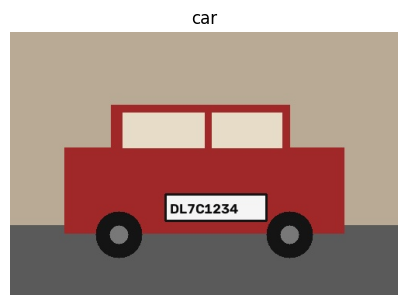

In [1]:
import sys, cv2, numpy as np
import matplotlib.pyplot as plt
sys.path.append('.')
import utils
img=utils.load_image(); print('image:', img.shape)
plt.figure(figsize=(5,4)); plt.imshow(img); plt.title('car'); plt.axis('off'); plt.show()

## 1. Edge map (bilateral filter keeps edges, then Canny)

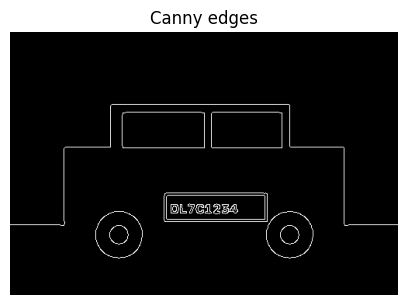

In [2]:
edges=utils.find_edges(img)
plt.figure(figsize=(5,4)); plt.imshow(edges,cmap='gray'); plt.title('Canny edges'); plt.axis('off'); plt.show()

## 2. Plate-shaped candidate rectangles

Keep contours whose bounding box has plate-like aspect ratio (3:1-6:1) and plate-like area (rejects the whole car body and the windows).

candidates (x,y,w,h,area,aspect):
   (198, 208, 134, 38, 5092, 3.5)
   (198, 208, 134, 38, 5092, 3.5)
   (201, 211, 128, 32, 4096, 4.0)
   (201, 211, 128, 32, 4096, 4.0)


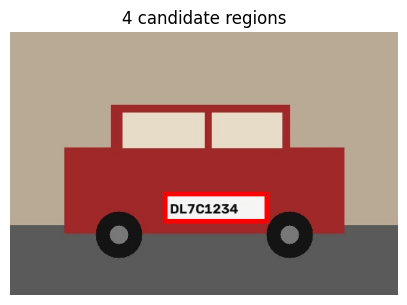

In [3]:
cands=utils.plate_candidates(edges)
print('candidates (x,y,w,h,area,aspect):')
for c in cands: print('  ', tuple(round(v,1) for v in c))
vis=img.copy()
for (x,y,w,h,a,ar) in cands: cv2.rectangle(vis,(x,y),(x+w,y+h),(255,0,0),2)
plt.figure(figsize=(5,4)); plt.imshow(vis); plt.title('%d candidate regions'%len(cands)); plt.axis('off'); plt.show()

### Finding
The aspect-ratio and area filters cut the many edge contours down to a handful of plate-shaped candidates. Notebook 02 picks the plate among them by brightness (a plate is a bright white rectangle).